In [1]:
import pandas as pd

df = pd.read_csv("StudentPerformanceFactors.csv")

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [2]:
#Check missing values before imputation
print("Missing values BEFORE imputation:")
print(df.isnull().sum())
print(f"\nTotal rows: {df.shape[0]}")


Missing values BEFORE imputation:
Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

Total rows: 6607


In [3]:
df["Teacher_Quality"] = df["Teacher_Quality"].fillna(df["Teacher_Quality"].mode()[0])
df["Parental_Education_Level"] = df["Parental_Education_Level"].fillna(df["Parental_Education_Level"].mode()[0])
df["Distance_from_Home"] = df["Distance_from_Home"].fillna(df["Distance_from_Home"].mode()[0])

In [4]:
#Verify — no more missing values
print("\nMissing values AFTER imputation:")
print(df.isnull().sum())



Missing values AFTER imputation:
Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64


In [5]:
print(df.select_dtypes(include=['object']).columns)

Index(['Parental_Involvement', 'Access_to_Resources',
       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender'],
      dtype='object')


In [6]:
print(df["Teacher_Quality"].unique())
print(df["Parental_Education_Level"].unique())
print(df["Distance_from_Home"].unique())

['Medium' 'High' 'Low']
['High School' 'College' 'Postgraduate']
['Near' 'Moderate' 'Far']


In [7]:
df_encoded = pd.get_dummies(df, drop_first=True)

print(df.shape)
print(df_encoded.shape)

(6607, 20)
(6607, 28)


In [8]:
print("Data types after encoding:")
print(df_encoded.dtypes)

print("\nAny object columns left?")
print(df_encoded.select_dtypes(include=['object']).columns)

Data types after encoding:
Hours_Studied                            int64
Attendance                               int64
Sleep_Hours                              int64
Previous_Scores                          int64
Tutoring_Sessions                        int64
Physical_Activity                        int64
Exam_Score                               int64
Parental_Involvement_Low                  bool
Parental_Involvement_Medium               bool
Access_to_Resources_Low                   bool
Access_to_Resources_Medium                bool
Extracurricular_Activities_Yes            bool
Motivation_Level_Low                      bool
Motivation_Level_Medium                   bool
Internet_Access_Yes                       bool
Family_Income_Low                         bool
Family_Income_Medium                      bool
Teacher_Quality_Low                       bool
Teacher_Quality_Medium                    bool
School_Type_Public                        bool
Peer_Influence_Neutral           

In [9]:
df_encoded = df_encoded.astype(int, errors='ignore')

print("Data types:")
print(df_encoded.dtypes)

Data types:
Hours_Studied                            int64
Attendance                               int64
Sleep_Hours                              int64
Previous_Scores                          int64
Tutoring_Sessions                        int64
Physical_Activity                        int64
Exam_Score                               int64
Parental_Involvement_Low                 int64
Parental_Involvement_Medium              int64
Access_to_Resources_Low                  int64
Access_to_Resources_Medium               int64
Extracurricular_Activities_Yes           int64
Motivation_Level_Low                     int64
Motivation_Level_Medium                  int64
Internet_Access_Yes                      int64
Family_Income_Low                        int64
Family_Income_Medium                     int64
Teacher_Quality_Low                      int64
Teacher_Quality_Medium                   int64
School_Type_Public                       int64
Peer_Influence_Neutral                   int64
P

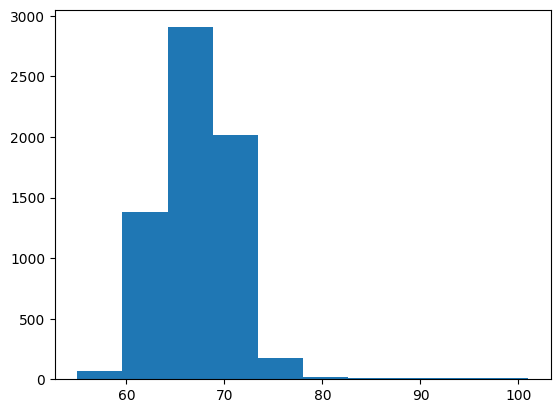

Mean: 67.23565914938702
Median: 67.0
Std: 3.890455781261724


In [10]:
import matplotlib.pyplot as plt

plt.hist(df_encoded["Exam_Score"])
plt.show()

print("Mean:", df_encoded["Exam_Score"].mean())
print("Median:", df_encoded["Exam_Score"].median())
print("Std:", df_encoded["Exam_Score"].std())

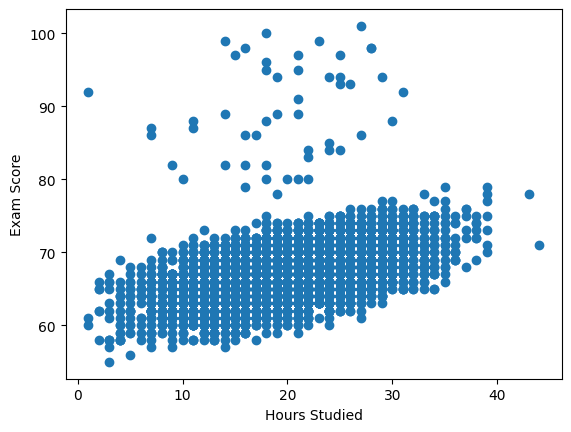

In [11]:
plt.scatter(df_encoded["Hours_Studied"], df_encoded["Exam_Score"])
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.show()

In [12]:
print("Correlation with Exam_Score:")
print(df_encoded.corr()["Exam_Score"])

Correlation with Exam_Score:
Hours_Studied                            0.445455
Attendance                               0.581072
Sleep_Hours                             -0.017022
Previous_Scores                          0.175079
Tutoring_Sessions                        0.156525
Physical_Activity                        0.027824
Exam_Score                               1.000000
Parental_Involvement_Low                -0.113602
Parental_Involvement_Medium             -0.035978
Access_to_Resources_Low                 -0.132155
Access_to_Resources_Medium              -0.026158
Extracurricular_Activities_Yes           0.064382
Motivation_Level_Low                    -0.080039
Motivation_Level_Medium                  0.024771
Internet_Access_Yes                      0.051475
Family_Income_Low                       -0.082025
Family_Income_Medium                     0.020995
Teacher_Quality_Low                     -0.041192
Teacher_Quality_Medium                  -0.043181
School_Type_Public   

In [13]:
from sklearn.preprocessing import MinMaxScaler

numerical_cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours',
                  'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']

scaler = MinMaxScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

print("Numerical features scaled to 0–1 range")

Numerical features scaled to 0–1 range


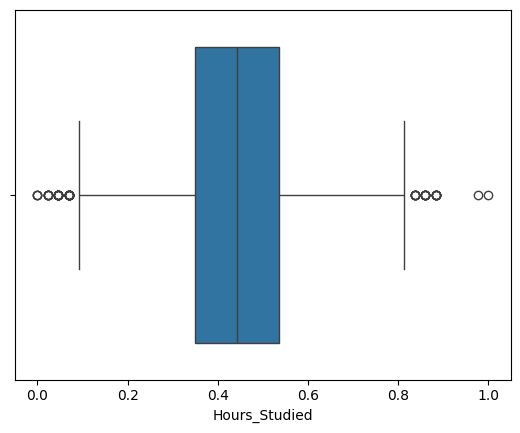

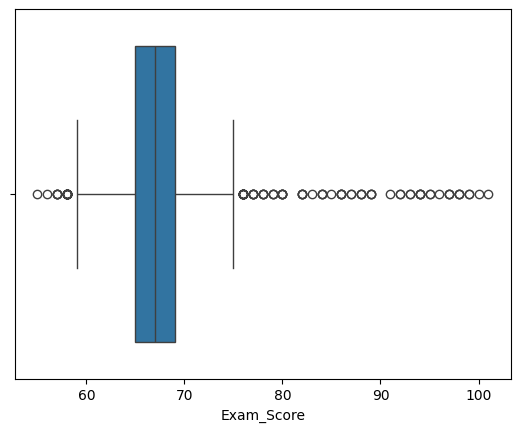

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df_encoded["Hours_Studied"])
plt.show()

sns.boxplot(x=df_encoded["Exam_Score"])
plt.show()

In [15]:
Q1 = df_encoded["Exam_Score"].quantile(0.25)
Q3 = df_encoded["Exam_Score"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_encoded["Exam_Score"] = df_encoded["Exam_Score"].clip(lower, upper)

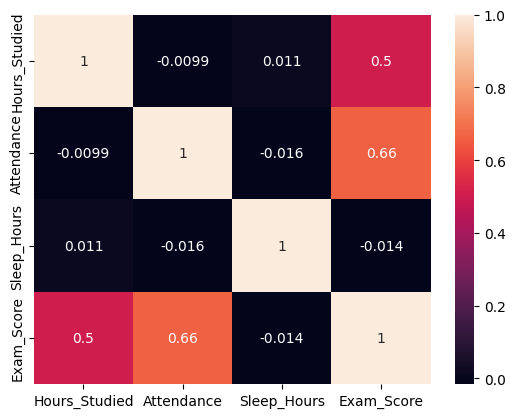

In [16]:
cols = ["Hours_Studied", "Attendance", "Sleep_Hours", "Exam_Score"]

import seaborn as sns
sns.heatmap(df_encoded[cols].corr(), annot=True)
plt.show()

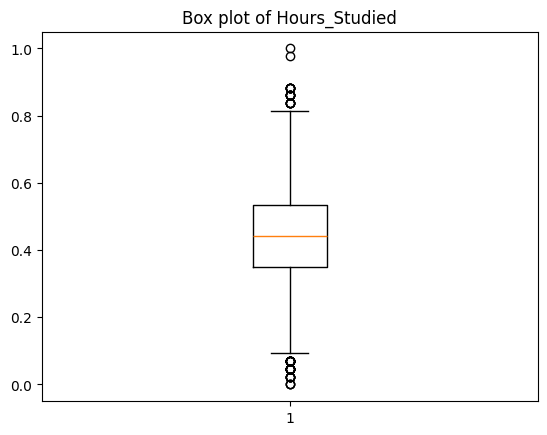

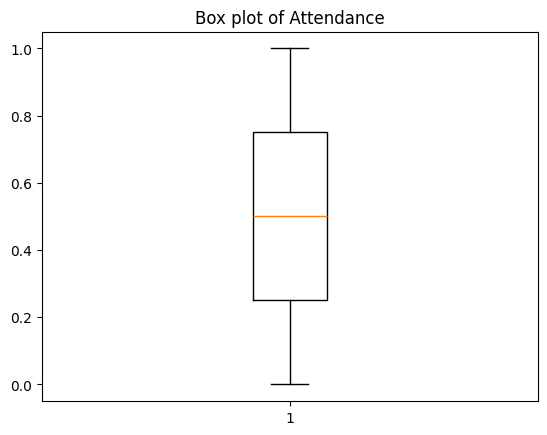

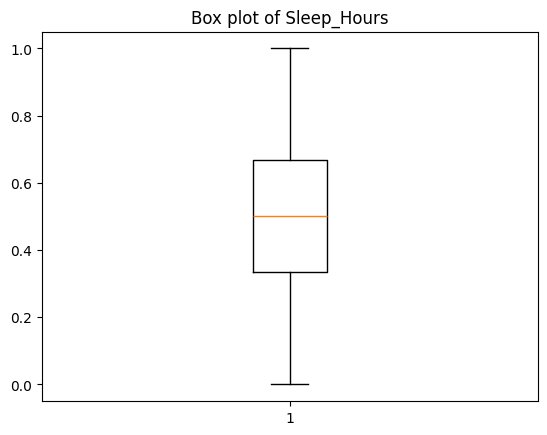

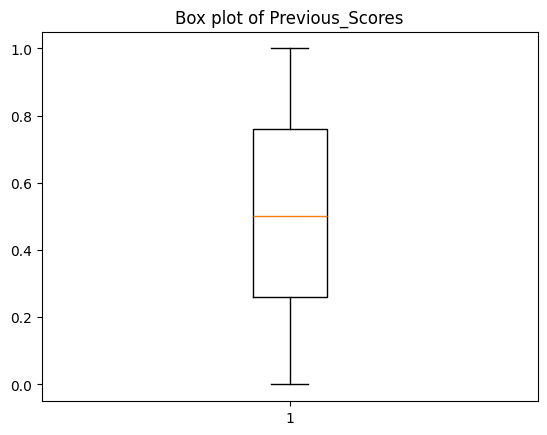

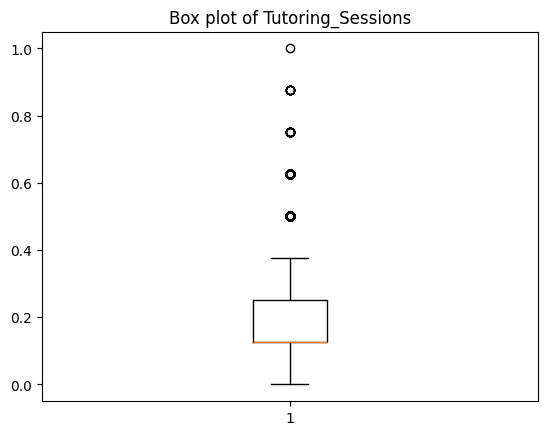

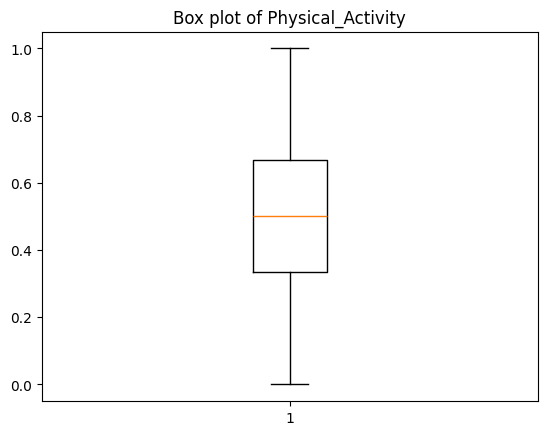

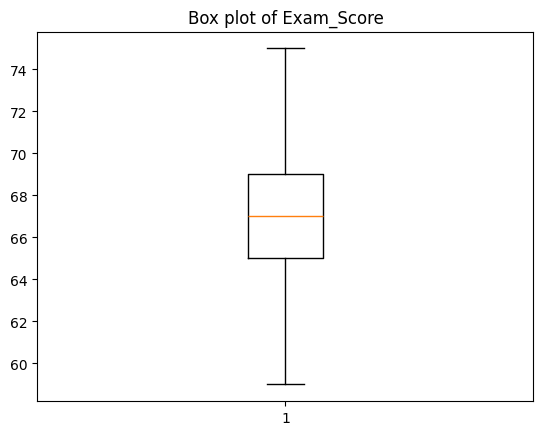

In [17]:
numerical_cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours',
                  'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']
for col in numerical_cols:
    plt.figure()
    plt.boxplot(df_encoded[col])
    plt.title(f"Box plot of {col}")
    plt.show()

In [18]:
print("Correlation with Exam_Score:")
correlation = df_encoded.corr()["Exam_Score"]
print(correlation)

cutoff = 0.05
columns_to_keep = correlation[abs(correlation) >= cutoff].index
df_selected = df_encoded[columns_to_keep]

print("Shape before:", df_encoded.shape)
print("Shape after: ", df_selected.shape)
print("Columns kept:", df_selected.columns.tolist())

Correlation with Exam_Score:
Hours_Studied                            0.504766
Attendance                               0.660555
Sleep_Hours                             -0.014136
Previous_Scores                          0.195737
Tutoring_Sessions                        0.175254
Physical_Activity                        0.037263
Exam_Score                               1.000000
Parental_Involvement_Low                -0.132811
Parental_Involvement_Medium             -0.033253
Access_to_Resources_Low                 -0.144618
Access_to_Resources_Medium              -0.031501
Extracurricular_Activities_Yes           0.068166
Motivation_Level_Low                    -0.090920
Motivation_Level_Medium                  0.028631
Internet_Access_Yes                      0.063424
Family_Income_Low                       -0.089128
Family_Income_Medium                     0.027721
Teacher_Quality_Low                     -0.047168
Teacher_Quality_Medium                  -0.044626
School_Type_Public   

In [19]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.ensemble import RandomForestRegressor

X = df_encoded.drop('Exam_Score', axis=1)
y = df_encoded['Exam_Score']

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance_sorted = importance.sort_values(ascending=False)

print("Top 10 Features by Random Forest Importance:\n")
for feature in importance_sorted.head(10).index:
    print(feature, "→ Importance:", round(importance_sorted[feature], 4),
          "| Correlation:", round(correlation[feature], 4))

Top 10 Features by Random Forest Importance:

Attendance → Importance: 0.456 | Correlation: 0.6606
Hours_Studied → Importance: 0.276 | Correlation: 0.5048
Previous_Scores → Importance: 0.0664 | Correlation: 0.1957
Tutoring_Sessions → Importance: 0.0327 | Correlation: 0.1753
Access_to_Resources_Low → Importance: 0.0211 | Correlation: -0.1446
Parental_Involvement_Low → Importance: 0.0206 | Correlation: -0.1328
Physical_Activity → Importance: 0.0144 | Correlation: 0.0373
Sleep_Hours → Importance: 0.0125 | Correlation: -0.0141
Peer_Influence_Positive → Importance: 0.008 | Correlation: 0.0911
Learning_Disabilities_Yes → Importance: 0.0078 | Correlation: -0.0995


In [20]:
scaler = MinMaxScaler()
X[numerical_cols[:-1]] = scaler.fit_transform(X[numerical_cols[:-1]])
print("Numerical features scaled to 0-1 range")

# -------------------------------
# Feature Selection Step 4: PCA
pca = PCA(n_components=0.95)  # Keep 95% variance
X_pca = pca.fit_transform(X)
print("Original features:", X.shape[1])
print("Features after PCA (95% variance):", X_pca.shape[1])

Numerical features scaled to 0-1 range
Original features: 27
Features after PCA (95% variance): 22


In [21]:
top_features = importance_sorted.head(6).index.tolist()
print("Selected features (beginner-friendly):", top_features)

Selected features (beginner-friendly): ['Attendance', 'Hours_Studied', 'Previous_Scores', 'Tutoring_Sessions', 'Access_to_Resources_Low', 'Parental_Involvement_Low']


In [22]:
final_features = ['Hours_Studied', 'Attendance', 'Previous_Scores',
                  'Tutoring_Sessions', 'Sleep_Hours', 'Physical_Activity']

# CORRELATION
print("\nFinal selected features with correlation:")
for f in final_features:
    print(f, "→", round(correlation[f], 4))

# Create final dataset
df_final = df_encoded[final_features + ['Exam_Score']]
print(f"Final dataset shape: {df_final.shape}")
print(f"Features: {final_features}")
print(f"Target: Exam_Score")

# Save final clean dataset
df_final.to_csv('student_performance_clean.csv', index=False)
print("\nSaved as 'student_performance_clean.csv'")


Final selected features with correlation:
Hours_Studied → 0.5048
Attendance → 0.6606
Previous_Scores → 0.1957
Tutoring_Sessions → 0.1753
Sleep_Hours → -0.0141
Physical_Activity → 0.0373
Final dataset shape: (6607, 7)
Features: ['Hours_Studied', 'Attendance', 'Previous_Scores', 'Tutoring_Sessions', 'Sleep_Hours', 'Physical_Activity']
Target: Exam_Score

Saved as 'student_performance_clean.csv'
